# COLAB SETUP

In [1]:
!git clone https://github.com/GeorgeVasile04/llm_lie_detection_black_vs_white_box.git

Cloning into 'llm_lie_detection_black_vs_white_box'...
remote: Enumerating objects: 1467, done.
remote: Counting objects: 100% (423/423), done.
remote: Compressing objects: 100% (328/328), done.
remote: Total 1467 (delta 191), reused 317 (delta 94), pack-reused 1044 (from 1)
Receiving objects: 100% (1467/1467), 84.23 MiB | 31.00 MiB/s, done.
Resolving deltas: 100% (690/690), done.


In [2]:
# Run this cell first if you are executing the notebook in Google Colab.
# It handles module dependencies and connects to your Google Drive to load your project.

try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab. Installing dependencies...")

    # 1. Install required packages
    get_ipython().system('pip install -q transformers accelerate datasets scikit-learn pandas')

    # 2. Mount Google Drive (if using Drive)
    from google.colab import drive
    drive.mount('/content/drive')

    # 3. Setup Project Path - More robust path detection
    import os, sys

    # First, try to find the project root by looking for the main folder
    possible_paths = [
        '/content/drive/MyDrive/llm_lie_detection_black_vs_white_box/Black_vs_White_Lie_Detection/Aligned_Comparison_BB_WB',
        '/content/llm_lie_detection_black_vs_white_box/Black_vs_White_Lie_Detection/Aligned_Comparison_BB_WB',
        os.path.join(os.getcwd(), 'Black_vs_White_Lie_Detection', 'Aligned_Comparison_BB_WB'),
        os.getcwd()  # If already in the right directory
    ]

    base_proj_path = None
    for path in possible_paths:
        if os.path.exists(path) and os.path.exists(os.path.join(path, 'load_data.py')):
            base_proj_path = path
            break

    if base_proj_path:
        os.chdir(base_proj_path)
        print(f"✅ Changed working directory to: {base_proj_path}")
    else:
        print("⚠️ Could not find project directory automatically. Please check your file structure.")
        print(f"Current directory: {os.getcwd()}")

    # Add current directory and parent directories to Python path
    current_dir = os.getcwd()
    if current_dir not in sys.path:
        sys.path.insert(0, current_dir)

    parent_dir = os.path.dirname(current_dir)
    if parent_dir not in sys.path:
        sys.path.insert(0, parent_dir)

    grandparent_dir = os.path.dirname(parent_dir)
    if grandparent_dir not in sys.path:
        sys.path.insert(0, grandparent_dir)

    print(f"✅ Python path updated. Current sys.path includes: {sys.path[:3]}...")

    # 4. Hugging Face Authentication (required for Llama models)
    print("\n🔐 IMPORTANT: Llama models require Hugging Face authentication.")
    print("If you haven't already:")
    print("1. Go to https://huggingface.co/meta-llama/Llama-2-7b-chat-hf")
    print("2. Accept the license agreement")
    print("3. Create a Hugging Face token at https://huggingface.co/settings/tokens")
    print("4. Add it to Colab Secrets (the 🔑 icon on the left) with the name 'HF_TOKEN'")
    print()

    try:
        from huggingface_hub import login
        from google.colab import userdata

        # Load token securely from Colab Secrets
        hf_token = userdata.get('HF_TOKEN')

        if hf_token:
            login(token=hf_token)
            print("✅ Successfully authenticated with Hugging Face!")
        else:
            print("⚠️ Secret 'HF_TOKEN' not found. Falling back to manual login...")
            login()
    except Exception as e:
        print(f"⚠️ Hugging Face login failed: {e}")
        print("Make sure you added the secret named 'HF_TOKEN' in the Colab sidebar.")

except ImportError:
    IN_COLAB = False
    print("Running locally. Setup skipped.")

Running in Google Colab. Installing dependencies...
Mounted at /content/drive
✅ Changed working directory to: /content/llm_lie_detection_black_vs_white_box/Black_vs_White_Lie_Detection/Aligned_Comparison_BB_WB
✅ Python path updated. Current sys.path includes: ['/content/llm_lie_detection_black_vs_white_box', '/content/llm_lie_detection_black_vs_white_box/Black_vs_White_Lie_Detection', '/content/llm_lie_detection_black_vs_white_box/Black_vs_White_Lie_Detection/Aligned_Comparison_BB_WB']...

🔐 IMPORTANT: Llama models require Hugging Face authentication.
If you haven't already:
1. Go to https://huggingface.co/meta-llama/Llama-2-7b-chat-hf
2. Accept the license agreement
3. Create a Hugging Face token at https://huggingface.co/settings/tokens
4. Add it to Colab Secrets (the 🔑 icon on the left) with the name 'HF_TOKEN'

✅ Successfully authenticated with Hugging Face!


# Imports and settings

In [3]:
import torch
import numpy as np
import pandas as pd
import time
import os
import pickle
from tqdm.auto import tqdm
from load_data import load_dataset_aligned
from wb_activations import load_model, get_activations_for_dataset
from bb_logprobs import compute_bb_features_for_dataset, compute_l1_yes_no_answers
from wb_probes import train_wb_probes
from bb_classifier import train_bb_classifier
from evaluation_utils import compare_results
from Black_vs_White_Lie_Detection.Class_Balance_Impact_BB_WB.wb_probes_imbalance import select_best_layer_cv

# Settings
MODEL_NAME = "meta-llama/Llama-2-7b-chat-hf"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


# 1. Load Dataset

In [ ]:
# Define ALL 15 datasets
DATASETS = [
    "commonsense_qa", "race", "arc_easy", "arc_challenge",
    "open_book_qa", "got_cities", "got_sp_en_trans", "got_larger_than", "imdb",
    "amazon_polarity", "ag_news", "dbpedia_14", "rte", "copa", "boolq"
]

# Datasets with specific hard-limits
EXACT_SIZE_DATASETS = [
    "commonsense_qa", "race", "arc_easy", "arc_challenge",
    "imdb", "open_book_qa", "boolq", "rte", "amazon_polarity",
    "ag_news", "dbpedia_14"
]

WB_BATCH_SIZE = 64
BB_BATCH_SIZE = 50

dataset_dict = {}
print(f"Loading {len(DATASETS)} datasets...\n")

start_time = time.time()
for ds_name in tqdm(DATASETS, desc="Loading datasets"):
    # Determine sizes based on whether it needs exact limits
    if ds_name in EXACT_SIZE_DATASETS:
        max_train = 5000
        max_val = 1000
    else:
        # We will split 5/6 Train and 1/6 Validation inside load_dataset_aligned if left dynamic
        max_train = 5000
        max_val = 1000

    # Load balanced
    ds_train_raw = load_dataset_aligned(ds_name, split='train', n_samples=max_train)
    ds_val_raw = load_dataset_aligned(ds_name, split='validation', n_samples=max_val)

    df_train = pd.DataFrame(ds_train_raw)
    df_val = pd.DataFrame(ds_val_raw)

    df = pd.concat([df_train, df_val], ignore_index=True)

    if len(df_train) > 0 and len(df_val) > 0:
        dataset_dict[ds_name] = df
        print(f"Loaded {len(df):,} samples for {ds_name} (train={len(df_train):,}, validation={len(df_val):,})")
    else:
        print(f"Skipped {ds_name}: missing data.")

elapsed = time.time() - start_time
print(f"\n✅ Step 1 Complete: Loaded {len(dataset_dict)} datasets")

Loading 15 datasets...



Loading datasets:   0%|          | 0/15 [00:00<?, ?it/s]

Loading commonsense_qa (split=train) using RepEng logic...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.25M [00:00<?, ?B/s]

...

boolq/test-00000-of-00001.parquet:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9427 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3270 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3245 [00:00<?, ? examples/s]

Loaded 5000 items.
Loading boolq (split=validation) using RepEng logic...
Loaded 1000 items.
Loaded 6,000 samples for boolq (train=5,000, validation=1,000)

✅ Step 1 Complete: Loaded 15 datasets


## 1b. Load Fixed-Prompt Datasets (race, copa, boolq — corrected prompts)

In [4]:
BB_BATCH_SIZE = 50  # also used in steps 4a-new and 4b-new

# These 3 datasets had structural prompt issues fixed in load_data.py:
#   - copa:  'question' field was the relation type ('cause'/'effect'), not a real question
#   - race:  article context was dropped from the prompt
#   - boolq: reading passage was dropped from the prompt
# We load them fresh here so corrected prompts flow through steps 3b, 4-new and 5-new
# while the original cached results remain untouched for comparison.

FIXED_DATASETS = ["race", "copa", "boolq"]

dataset_dict_new = {}
print(f"Loading {len(FIXED_DATASETS)} datasets with corrected prompts...\n")

start_time = time.time()
for ds_name in tqdm(FIXED_DATASETS, desc="Loading fixed-prompt datasets"):
    ds_train_raw = load_dataset_aligned(ds_name, split='train', n_samples=5000)
    ds_val_raw   = load_dataset_aligned(ds_name, split='validation', n_samples=1000)

    df_train = pd.DataFrame(ds_train_raw)
    df_val   = pd.DataFrame(ds_val_raw)
    df       = pd.concat([df_train, df_val], ignore_index=True)

    if len(df_train) > 0 and len(df_val) > 0:
        dataset_dict_new[ds_name] = df
        print(f"  {ds_name}_new: {len(df):,} samples  (train={len(df_train):,}, val={len(df_val):,})")
    else:
        print(f"  Skipped {ds_name}: missing data.")

elapsed = time.time() - start_time
print(f"\n✅ Step 1b Complete: {len(dataset_dict_new)} fixed-prompt datasets loaded in {elapsed:.1f}s")


Loading 3 datasets with corrected prompts...



Loading fixed-prompt datasets:   0%|          | 0/3 [00:00<?, ?it/s]

Loading race (split=train) using RepEng logic...


README.md: 0.00B [00:00, ?B/s]

all/test-00000-of-00001.parquet:   0%|          | 0.00/2.08M [00:00<?, ?B/s]

...

boolq/test-00000-of-00001.parquet:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9427 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3270 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3245 [00:00<?, ? examples/s]

Loaded 5000 items.
Loading boolq (split=validation) using RepEng logic...
Loaded 1000 items.
  boolq_new: 6,000 samples  (train=5,000, val=1,000)

✅ Step 1b Complete: 3 fixed-prompt datasets loaded in 29.9s


# 2. Load Model

In [5]:

print("Step 2: Loading model...")
import time  # Ensure time is available
start_time = time.time()
model, tokenizer = load_model(MODEL_NAME, device=DEVICE)
elapsed = time.time() - start_time
print(f"✅ Step 2 Complete: Model loaded in {elapsed:.1f}s")

Step 2: Loading model...
Loading model: meta-llama/Llama-2-7b-chat-hf...


config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

✅ Step 2 Complete: Model loaded in 40.1s


# 3. White Box: Extract Activations

In [ ]:
wb_data_dict = {}

print("Step 3: Extracting White Box Activations...")
start_time = time.time()
outer_pbar = tqdm(dataset_dict.keys(), desc="Overall PB: Extracting WB activations")
for ds_name in outer_pbar:
    # Dynamically lower batch size for memory-heavy datasets like IMDB
    current_batch_size = 28 if ds_name == "imdb" else WB_BATCH_SIZE

    df = dataset_dict[ds_name]
    df_train = df[df["split"] == "train"].reset_index(drop=True)
    df_validation = df[df["split"] == "validation"].reset_index(drop=True)
    outer_pbar.set_description(f"WB Activations: {ds_name} (train/val)")
    wb_train = get_activations_for_dataset(df_train, model, tokenizer, device=DEVICE, batch_size=current_batch_size, show_progress=True)
    wb_validation = get_activations_for_dataset(df_validation, model, tokenizer, device=DEVICE, batch_size=current_batch_size, show_progress=True)
    wb_data_dict[ds_name] = {
        "train": wb_train,
        "validation": wb_validation,
    }

elapsed = time.time() - start_time
print(f"\n✅ Step 3 Complete: White Box activations extracted for {len(wb_data_dict)} datasets in {elapsed:.1f}s")

Step 3: Extracting White Box Activations...


Overall PB: Extracting WB activations:   0%|          | 0/15 [00:00<?, ?it/s]

Extracting activations (batch_size=64):   0%|          | 0/79 [00:00<?, ?it/s]

Extracting activations (batch_size=64):   0%|          | 0/16 [00:00<?, ?it/s]

Extracting activations (batch_size=64):   0%|          | 0/79 [00:00<?, ?it/s]

...

Extracting activations (batch_size=64):   0%|          | 0/10 [00:00<?, ?it/s]

Extracting activations (batch_size=64):   0%|          | 0/4 [00:00<?, ?it/s]

Extracting activations (batch_size=64):   0%|          | 0/79 [00:00<?, ?it/s]

Extracting activations (batch_size=64):   0%|          | 0/16 [00:00<?, ?it/s]


✅ Step 3 Complete: White Box activations extracted for 15 datasets in 705.4s


## 3b. White Box: Extract Activations — Fixed-Prompt Datasets

In [6]:
wb_data_dict_new = {}
print("Step 3b: Extracting WB Activations for fixed-prompt datasets...")
start_time = time.time()
for ds_name in tqdm(FIXED_DATASETS, desc="WB Activations (new prompts)"):
    df       = dataset_dict_new[ds_name]
    df_train = df[df["split"] == "train"].reset_index(drop=True)
    df_val   = df[df["split"] == "validation"].reset_index(drop=True)
    # RACE now includes full articles — reduce batch size to avoid GPU OOM
    print(f"  Extracting {ds_name}_new  (batch_size=28)...")
    wb_train = get_activations_for_dataset(
        df_train, model, tokenizer, device=DEVICE,
        batch_size=28, show_progress=True
    )
    wb_val = get_activations_for_dataset(
        df_val, model, tokenizer, device=DEVICE,
        batch_size=28, show_progress=True
    )
    wb_data_dict_new[ds_name] = {"train": wb_train, "validation": wb_val}
    print(f"  ✅ {ds_name}_new: {len(wb_train)} train activations, {len(wb_val)} val activations")
elapsed = time.time() - start_time
print(f"\n✅ Step 3b Complete: WB activations extracted in {elapsed:.1f}s")


Step 3b: Extracting WB Activations for fixed-prompt datasets...


WB Activations (new prompts):   0%|          | 0/3 [00:00<?, ?it/s]

  Extracting race_new  (batch_size=28)...


Extracting activations (batch_size=28):   0%|          | 0/179 [00:00<?, ?it/s]

Extracting activations (batch_size=28):   0%|          | 0/36 [00:00<?, ?it/s]

...

Extracting activations (batch_size=28):   0%|          | 0/8 [00:00<?, ?it/s]

  ✅ copa_new: 620 train activations, 200 val activations
  Extracting boolq_new  (batch_size=28)...


Extracting activations (batch_size=28):   0%|          | 0/179 [00:00<?, ?it/s]

Extracting activations (batch_size=28):   0%|          | 0/36 [00:00<?, ?it/s]

  ✅ boolq_new: 5000 train activations, 1000 val activations

✅ Step 3b Complete: WB activations extracted in 338.6s


# 4. Black Box: Compute Logprobs

In [7]:
# Load the exact elicitation questions used in the original Black Box paper
# The paper selected 48 probes organized into 3 groups: lie, no_lie, and knowable
import numpy as np

try:
    # Load the original paper's probe indices from the Black Box project
    no_lie_indices = np.load("../../Black_Box_Lie_Detection/results/probes_groups/no_lie_indices.npy")
    lie_indices = np.load("../../Black_Box_Lie_Detection/results/probes_groups/lie_indices.npy")
    knowable_indices = np.load("../../Black_Box_Lie_Detection/results/probes_groups/knowable_indices.npy")

    # Concatenate to get the union (48 probes total)
    PAPER_PROBE_INDICES = np.concatenate([no_lie_indices, lie_indices, knowable_indices])
    print(f"✅ Loaded {len(PAPER_PROBE_INDICES)} elicitation questions (exact same as original paper)")
    print(f"   Probe categories: {len(no_lie_indices)} no_lie + {len(lie_indices)} lie + {len(knowable_indices)} knowable")

except FileNotFoundError as e:
    print(f"⚠️ Warning: Could not load original paper's probe indices: {e}")
    print("Will use all available probes instead.")
    PAPER_PROBE_INDICES = None

✅ Loaded 48 elicitation questions (exact same as original paper)
   Probe categories: 14 no_lie + 24 lie + 10 knowable


In [ ]:
l2_data_dict = {}

os.makedirs("bb_elicitation_vectors_lvl_2", exist_ok=True)
DATA_EFF_PATH = os.path.join("..", "Data_Efficiency_BB_WB", "outputs")

print("Step 4a: Computing/Loading Level 2 (Logprobs) Features...")
start_time = time.time()

datasets_list = list(dataset_dict.keys())
with tqdm(total=len(datasets_list), desc="Step 4a — L2 Logprobs", unit="dataset") as pbar:
    for ds_name in datasets_list:
        df = dataset_dict[ds_name]
        df_train = df[df["split"] == "train"].reset_index(drop=True)
        df_validation = df[df["split"] == "validation"].reset_index(drop=True)

        data_eff_path = os.path.join(DATA_EFF_PATH, f"{ds_name}_bb_features_efficiency.pkl")
        local_l2_path = os.path.join("bb_elicitation_vectors_lvl_2", f"{ds_name}_bb_features_lvl2.pkl")

        if os.path.exists(data_eff_path):
            pbar.set_postfix(dataset=ds_name, source="Exp2 cache")
            with open(data_eff_path, "rb") as f:
                cached = pickle.load(f)
            X_train_l2, y_train_l2 = cached["train_full"]
            X_validation_l2, y_validation_l2 = cached["validation"]

        elif os.path.exists(local_l2_path):
            pbar.set_postfix(dataset=ds_name, source="local cache")
            with open(local_l2_path, "rb") as f:
                cached = pickle.load(f)
            X_train_l2, y_train_l2 = cached["train"]
            X_validation_l2, y_validation_l2 = cached["validation"]

        else:
            pbar.set_postfix(dataset=ds_name, source="computing...")
            bb_train = compute_bb_features_for_dataset(
                df_train, model, tokenizer, device=DEVICE,
                batch_size=BB_BATCH_SIZE, probe_indices=PAPER_PROBE_INDICES, show_progress=True
            )
            bb_val = compute_bb_features_for_dataset(
                df_validation, model, tokenizer, device=DEVICE,
                batch_size=BB_BATCH_SIZE, probe_indices=PAPER_PROBE_INDICES, show_progress=True
            )

            X_train_list, y_train_list = [], []
            for res in bb_train:
                if not res.get("bb_features"):
                    continue
                X_train_list.append([p["score"] for p in res["bb_features"]])
                y_train_list.append(res["label"])

            X_val_list, y_val_list = [], []
            for res in bb_val:
                if not res.get("bb_features"):
                    continue
                X_val_list.append([p["score"] for p in res["bb_features"]])
                y_val_list.append(res["label"])

            X_train_l2, y_train_l2 = np.array(X_train_list), np.array(y_train_list)
            X_validation_l2, y_validation_l2 = np.array(X_val_list), np.array(y_val_list)

            with open(local_l2_path, "wb") as f:
                pickle.dump(
                    {"train": (X_train_l2, y_train_l2), "validation": (X_validation_l2, y_validation_l2)}, f
                )

        l2_data_dict[ds_name] = {
            "X_train": X_train_l2, "y_train": y_train_l2,
            "X_validation": X_validation_l2, "y_validation": y_validation_l2,
        }
        pbar.update(1)

elapsed = time.time() - start_time
print(f"\n✅ Step 4a Complete: L2 features ready for {len(l2_data_dict)} datasets in {elapsed:.1f}s")


Step 4a: Computing/Loading Level 2 (Logprobs) Features...


Step 4a — L2 Logprobs:   0%|          | 0/15 [00:00<?, ?dataset/s]


✅ Step 4a Complete: L2 features ready for 15 datasets in 0.0s


## 4a-new. Black Box: L2 Logprobs — Fixed-Prompt Datasets (force-recompute, no cache)

In [8]:
from bb_logprobs import compute_l2_logprob_features

l2_data_dict_new = {}
os.makedirs("bb_elicitation_vectors_lvl_2", exist_ok=True)

print("Step 4a-new: Computing L2 (Logprobs) features for fixed-prompt datasets...")
start_time = time.time()

for ds_name in FIXED_DATASETS:
    df       = dataset_dict_new[ds_name]
    df_train = df[df["split"] == "train"].reset_index(drop=True)
    df_val   = df[df["split"] == "validation"].reset_index(drop=True)

    # RACE prompts now include full articles — reduce elicitation batch to avoid GPU OOM
    eb = 48 if ds_name == "race" else 48
    print(f"  {ds_name}_new  (elicitation_batch_size={eb})...")

    train_results = compute_l2_logprob_features(
        df_train, model, tokenizer, device=DEVICE,
        probe_indices=PAPER_PROBE_INDICES, show_progress=True,
        elicitation_batch_size=eb, desc=f"{ds_name}_new [train]"
    )
    val_results = compute_l2_logprob_features(
        df_val, model, tokenizer, device=DEVICE,
        probe_indices=PAPER_PROBE_INDICES, show_progress=True,
        elicitation_batch_size=eb, desc=f"{ds_name}_new [val]"
    )

    X_train_l2 = np.array([r["l2_features"] for r in train_results])
    y_train_l2 = np.array([r["label"]       for r in train_results])
    X_val_l2   = np.array([r["l2_features"] for r in val_results])
    y_val_l2   = np.array([r["label"]       for r in val_results])

    save_path = os.path.join("bb_elicitation_vectors_lvl_2", f"{ds_name}_new_bb_features_lvl2.pkl")
    with open(save_path, "wb") as f:
        pickle.dump({"train": (X_train_l2, y_train_l2), "validation": (X_val_l2, y_val_l2)}, f)

    l2_data_dict_new[ds_name] = {
        "X_train": X_train_l2, "y_train": y_train_l2,
        "X_validation": X_val_l2, "y_validation": y_val_l2,
    }
    print(f"  {ds_name}_new: L2 saved -> {save_path}")

elapsed = time.time() - start_time
print(f"Step 4a-new Complete: L2 features computed in {elapsed:.1f}s")


Step 4a-new: Computing L2 (Logprobs) features for fixed-prompt datasets...
  race_new  (elicitation_batch_size=48)...


race_new [train]:   0%|          | 0/5000 [00:00<?, ?sample/s]

race_new [val]:   0%|          | 0/1000 [00:00<?, ?sample/s]

  race_new: L2 saved -> bb_elicitation_vectors_lvl_2/race_new_bb_features_lvl2.pkl
  copa_new  (elicitation_batch_size=48)...


copa_new [train]:   0%|          | 0/620 [00:00<?, ?sample/s]

copa_new [val]:   0%|          | 0/200 [00:00<?, ?sample/s]

  copa_new: L2 saved -> bb_elicitation_vectors_lvl_2/copa_new_bb_features_lvl2.pkl
  boolq_new  (elicitation_batch_size=48)...


boolq_new [train]:   0%|          | 0/5000 [00:00<?, ?sample/s]

boolq_new [val]:   0%|          | 0/1000 [00:00<?, ?sample/s]

  boolq_new: L2 saved -> bb_elicitation_vectors_lvl_2/boolq_new_bb_features_lvl2.pkl
Step 4a-new Complete: L2 features computed in 10739.5s


In [ ]:
l1_data_dict = {}

os.makedirs("bb_elicitation_vectors_lvl_1", exist_ok=True)

print("Step 4b: Computing/Loading Level 1 (Yes/No) Features...")
start_time = time.time()

datasets_list = list(dataset_dict.keys())
with tqdm(total=len(datasets_list), desc="Step 4b — L1 Yes/No", unit="dataset") as outer_pbar:
    for ds_name in datasets_list:
        df = dataset_dict[ds_name]
        df_train = df[df["split"] == "train"].reset_index(drop=True)
        df_validation = df[df["split"] == "validation"].reset_index(drop=True)

        local_l1_path = os.path.join("bb_elicitation_vectors_lvl_1", f"{ds_name}_bb_features_lvl1.pkl")

        if os.path.exists(local_l1_path):
            outer_pbar.set_postfix(dataset=ds_name, source="local cache")
            with open(local_l1_path, "rb") as f:
                cached = pickle.load(f)
            X_train_l1, y_train_l1 = cached["train"]
            X_validation_l1, y_validation_l1 = cached["validation"]

        else:
            outer_pbar.set_postfix(dataset=ds_name, source="computing...")

            l1_train = compute_l1_yes_no_answers(
                df_train, model, tokenizer, device=DEVICE,
                batch_size=BB_BATCH_SIZE, probe_indices=PAPER_PROBE_INDICES,
                show_progress=True, desc=f"{ds_name} [train] — {len(df_train)} samples"
            )

            l1_val = compute_l1_yes_no_answers(
                df_validation, model, tokenizer, device=DEVICE,
                batch_size=BB_BATCH_SIZE, probe_indices=PAPER_PROBE_INDICES,
                show_progress=True, desc=f"{ds_name} [val]   — {len(df_validation)} samples"
            )

            X_train_l1 = np.array([res["l1_features"] for res in l1_train])
            y_train_l1 = np.array([res["label"] for res in l1_train])
            X_validation_l1 = np.array([res["l1_features"] for res in l1_val])
            y_validation_l1 = np.array([res["label"] for res in l1_val])

            with open(local_l1_path, "wb") as f:
                pickle.dump({"train": (X_train_l1, y_train_l1), "validation": (X_validation_l1, y_validation_l1)}, f)

            print(f"  ✅ {ds_name} — L1 extraction succeeded (train={len(X_train_l1)}, val={len(X_validation_l1)})")

        l1_data_dict[ds_name] = {
            "X_train": X_train_l1, "y_train": y_train_l1,
            "X_validation": X_validation_l1, "y_validation": y_validation_l1,
        }
        outer_pbar.update(1)

elapsed = time.time() - start_time
print(f"✅ Step 4b Complete: L1 features ready for {len(l1_data_dict)} datasets in {elapsed:.1f}s")


Step 4b: Computing/Loading Level 1 (Yes/No) Features...


Step 4b — L1 Yes/No:   0%|          | 0/15 [00:00<?, ?dataset/s]

✅ Step 4b Complete: L1 features ready for 15 datasets in 0.0s


## 4b-new. Black Box: L1 Yes/No — Fixed-Prompt Datasets (force-recompute, no cache)

In [9]:
l1_data_dict_new = {}
os.makedirs("bb_elicitation_vectors_lvl_1", exist_ok=True)

print("Step 4b-new: Computing L1 (Yes/No) features for fixed-prompt datasets (no cache)...")
start_time = time.time()

for ds_name in tqdm(FIXED_DATASETS, desc="L1 Yes/No (new prompts)"):
    df       = dataset_dict_new[ds_name]
    df_train = df[df["split"] == "train"].reset_index(drop=True)
    df_val   = df[df["split"] == "validation"].reset_index(drop=True)

    print(f"  Computing {ds_name}_new L1 features...")

    l1_train = compute_l1_yes_no_answers(
        df_train, model, tokenizer, device=DEVICE,
        batch_size=BB_BATCH_SIZE, probe_indices=PAPER_PROBE_INDICES,
        show_progress=True, desc=f"{ds_name}_new [train]"
    )
    l1_val = compute_l1_yes_no_answers(
        df_val, model, tokenizer, device=DEVICE,
        batch_size=BB_BATCH_SIZE, probe_indices=PAPER_PROBE_INDICES,
        show_progress=True, desc=f"{ds_name}_new [val]"
    )

    X_train_l1 = np.array([r["l1_features"] for r in l1_train])
    y_train_l1 = np.array([r["label"]       for r in l1_train])
    X_val_l1   = np.array([r["l1_features"] for r in l1_val])
    y_val_l1   = np.array([r["label"]       for r in l1_val])

    save_path = os.path.join("bb_elicitation_vectors_lvl_1", f"{ds_name}_new_bb_features_lvl1.pkl")
    with open(save_path, "wb") as f:
        pickle.dump({"train": (X_train_l1, y_train_l1), "validation": (X_val_l1, y_val_l1)}, f)

    l1_data_dict_new[ds_name] = {
        "X_train": X_train_l1, "y_train": y_train_l1,
        "X_validation": X_val_l1, "y_validation": y_val_l1,
    }
    print(f"  ✅ {ds_name}_new: L1 saved → {save_path}")

elapsed = time.time() - start_time
print(f"\n✅ Step 4b-new Complete: L1 features computed in {elapsed:.1f}s")

Step 4b-new: Computing L1 (Yes/No) features for fixed-prompt datasets (no cache)...


L1 Yes/No (new prompts):   0%|          | 0/3 [00:00<?, ?it/s]

  Computing race_new L1 features...


race_new [train]:   0%|          | 0/5000 [00:00<?, ?sample/s]

race_new [val]:   0%|          | 0/1000 [00:00<?, ?sample/s]

...

copa_new [val]:   0%|          | 0/200 [00:00<?, ?sample/s]

  ✅ copa_new: L1 saved → bb_elicitation_vectors_lvl_1/copa_new_bb_features_lvl1.pkl
  Computing boolq_new L1 features...


boolq_new [train]:   0%|          | 0/5000 [00:00<?, ?sample/s]

boolq_new [val]:   0%|          | 0/1000 [00:00<?, ?sample/s]

  ✅ boolq_new: L1 saved → bb_elicitation_vectors_lvl_1/boolq_new_bb_features_lvl1.pkl

✅ Step 4b-new Complete: L1 features computed in 10686.1s


# 5. Train & Evaluate Classifiers

In [10]:
print("Step 5: Training Classifiers (L1, L2, L3)")
all_comparisons = []
LAYER_LIST = list(range(1, 33))
print(f"Testing the following layers: {LAYER_LIST}")

wb_methods = ["lr", "dim", "lat", "ccs", "lda", "pca", "pca-g", "lr-g"]
method_names_map = {
    "lr": "Logistic Regression",
    "dim": "Difference in Means",
    "lat": "Linear Artificial Tomography",
    "ccs": "Contrast-Consistent Search",
    "lda": "Linear Discriminant Analysis",
    "pca": "Principal Component Analysis",
    "pca-g": "Grouped PCA",
    "lr-g": "Grouped Logistic Regression",
}

Step 5: Training Classifiers (L1, L2, L3)
Testing the following layers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]


In [ ]:
import pickle
import os

l1_results = []
datasets_list = list(l1_data_dict.keys())
with tqdm(total=len(datasets_list), desc="Step 5 — L1 Classifiers", unit="dataset") as pbar:
    for ds_name in datasets_list:
        pbar.set_postfix(dataset=ds_name)
        X_train, y_train = l1_data_dict[ds_name]["X_train"], l1_data_dict[ds_name]["y_train"]
        X_test, y_test = l1_data_dict[ds_name]["X_validation"], l1_data_dict[ds_name]["y_validation"]

        bb_model, bb_metric = train_bb_classifier(X_train, X_test, y_train, y_test)
        bb_metric.update({"Dataset": ds_name, "Access_Level": "Level 1 (Yes/No)"})
        l1_results.append(bb_metric)
        pbar.update(1)

pd.DataFrame(l1_results).to_csv("level1_results.csv", index=False)
print("✅ Saved Level 1 results to level1_results.csv")


Step 5 — L1 Classifiers:   0%|          | 0/15 [00:00<?, ?dataset/s]

Training Black Box Classifier...
Black Box Results - AUC: 0.7271, MAP: 0.4077, BRP_90: 0.0100
Training Black Box Classifier...
Black Box Results - AUC: 0.5851, MAP: 0.3153, BRP_90: 0.0000
Training Black Box Classifier...
Black Box Results - AUC: 0.8326, MAP: 0.5953, BRP_90: 0.0040
Training Black Box Classifier...
Black Box Results - AUC: 0.6802, MAP: 0.3980, BRP_90: 0.0000
Training Black Box Classifier...
Black Box Results - AUC: 0.7378, MAP: 0.4881, BRP_90: 0.0040
Training Black Box Classifier...
Black Box Results - AUC: 0.9508, MAP: 0.9509, BRP_90: 0.7954
Training Black Box Classifier...
Black Box Results - AUC: 0.9104, MAP: 0.9157, BRP_90: 0.6897
Training Black Box Classifier...
Black Box Results - AUC: 0.8427, MAP: 0.8686, BRP_90: 0.6465
Training Black Box Classifier...
Black Box Results - AUC: 0.9534, MAP: 0.9528, BRP_90: 0.8580
Training Black Box Classifier...
Black Box Results - AUC: 0.9722, MAP: 0.9700, BRP_90: 0.9280
Training Black Box Classifier...
Black Box Results - AUC: 0.

In [ ]:
os.makedirs("classifiers/level2", exist_ok=True)

l2_results = []
datasets_list = list(l2_data_dict.keys())
with tqdm(total=len(datasets_list), desc="Step 5 — L2 Classifiers", unit="dataset") as pbar:
    for ds_name in datasets_list:
        pbar.set_postfix(dataset=ds_name)
        X_train, y_train = l2_data_dict[ds_name]["X_train"], l2_data_dict[ds_name]["y_train"]
        X_test, y_test = l2_data_dict[ds_name]["X_validation"], l2_data_dict[ds_name]["y_validation"]

        bb_bundle, bb_metric = train_bb_classifier(X_train, X_test, y_train, y_test)
        bb_metric.update({"Dataset": ds_name, "Access_Level": "Level 2 (Logprobs)"})
        l2_results.append(bb_metric)

        # Save clf + scaler together so Experiment 4 can apply the source scaler to target datasets
        with open(f"classifiers/level2/{ds_name}_l2_classifier.pkl", "wb") as f:
            pickle.dump(bb_bundle, f)
        pbar.update(1)

pd.DataFrame(l2_results).to_csv("level2_results.csv", index=False)
print("✅ Saved Level 2 results to level2_results.csv")


Step 5 — L2 Classifiers:   0%|          | 0/15 [00:00<?, ?dataset/s]

Training Black Box Classifier...
Black Box Results - AUC: 0.7524, MAP: 0.7364, BRP_90: 0.1000
Training Black Box Classifier...
Black Box Results - AUC: 0.7505, MAP: 0.7343, BRP_90: 0.0460
Training Black Box Classifier...
Black Box Results - AUC: 0.8748, MAP: 0.8717, BRP_90: 0.4180
Training Black Box Classifier...
Black Box Results - AUC: 0.7183, MAP: 0.4431, BRP_90: 0.0120
Training Black Box Classifier...
Black Box Results - AUC: 0.7455, MAP: 0.7315, BRP_90: 0.0820
Training Black Box Classifier...
Black Box Results - AUC: 0.9994, MAP: 0.9994, BRP_90: 1.0000
Training Black Box Classifier...
Black Box Results - AUC: 0.9822, MAP: 0.9371, BRP_90: 1.0000
Training Black Box Classifier...
Black Box Results - AUC: 0.9825, MAP: 0.9844, BRP_90: 0.9419
Training Black Box Classifier...
Black Box Results - AUC: 0.6441, MAP: 0.6786, BRP_90: 0.0020
Training Black Box Classifier...
Black Box Results - AUC: 0.8019, MAP: 0.7817, BRP_90: 0.1380
Training Black Box Classifier...
Black Box Results - AUC: 0.

In [ ]:
os.makedirs("classifiers/level3", exist_ok=True)

# Load any previously saved intermediate results
l3_results = []
if os.path.exists("outputs/level3_results.csv"):
    l3_results = pd.read_csv("outputs/level3_results.csv").to_dict("records")
    already_done_l3 = {(r["Dataset"], r["Method"]) for r in l3_results}
    print(f"Loaded {len(l3_results)} existing results from outputs/level3_results.csv")
elif os.path.exists("level3_results.csv"):
    l3_results = pd.read_csv("level3_results.csv").to_dict("records")
    already_done_l3 = {(r["Dataset"], r["Method"]) for r in l3_results}
    print(f"Loaded {len(l3_results)} existing results from level3_results.csv")
else:
    already_done_l3 = set()
    print("No existing L3 results found — starting from scratch.")

datasets_list = list(wb_data_dict.keys())
with tqdm(total=len(datasets_list), desc="Step 5 — L3 Classifiers", unit="dataset") as outer_pbar:
    for ds_name in datasets_list:
        all_methods_done = all(
            (ds_name, method_names_map[m]) in already_done_l3 for m in wb_methods
        )
        if all_methods_done:
            outer_pbar.set_postfix(dataset=ds_name, status="fully skipped")
            print(f"  ⏭ {ds_name}: all {len(wb_methods)} methods already in CSV — skipping.")
            outer_pbar.update(1)
            continue

        wb_train = wb_data_dict[ds_name]["train"]
        wb_validation = wb_data_dict[ds_name]["validation"]

        with tqdm(total=len(wb_methods), desc=f"  {ds_name}", unit="method", leave=False) as method_pbar:
            for method in wb_methods:
                method_full = method_names_map[method]
                clf_path = f"classifiers/level3/{ds_name}_{method}_l3_classifier.pkl"

                if (ds_name, method_full) in already_done_l3:
                    method_pbar.set_postfix(method=method, stage="skipped (in CSV)")
                    method_pbar.update(1)
                    continue

                method_pbar.set_postfix(method=method, stage="CV layer selection")
                best_layer = select_best_layer_cv(
                    wb_train, layer_list=LAYER_LIST, method=method, n_splits=4, verbose=False
                )

                method_pbar.set_postfix(method=method, stage=f"training L{best_layer}")
                trained_probes, wb_metrics = train_wb_probes(
                    wb_train, eval_data=wb_validation, layer_list=[best_layer], method=method
                )

                metrics = wb_metrics[best_layer]
                metrics.update({
                    "Dataset": ds_name, "Access_Level": "Level 3",
                    "Method": method_full, "Layer": best_layer,
                })
                l3_results.append(metrics)

                best_probe = trained_probes[best_layer]
                with open(clf_path, "wb") as f:
                    pickle.dump(best_probe, f)
                method_pbar.update(1)

        # Intermediate save after every completed dataset
        pd.DataFrame(l3_results).to_csv("outputs/level3_results.csv", index=False)
        outer_pbar.set_postfix(dataset=ds_name, saved=len(l3_results))
        outer_pbar.update(1)

print(f"\n✅ Step 5 L3 Complete: {len(l3_results)} results saved to outputs/level3_results.csv")


Loaded 64 existing results from outputs/level3_results.csv


Step 5 — L3 Classifiers:   0%|          | 0/15 [00:00<?, ?dataset/s]

  ⏭ commonsense_qa: all 8 methods already in CSV — skipping.
  ⏭ race: all 8 methods already in CSV — skipping.
  ⏭ arc_easy: all 8 methods already in CSV — skipping.
  ⏭ arc_challenge: all 8 methods already in CSV — skipping.
  ⏭ open_book_qa: all 8 methods already in CSV — skipping.
  ⏭ got_cities: all 8 methods already in CSV — skipping.
  ⏭ got_sp_en_trans: all 8 methods already in CSV — skipping.
  ⏭ got_larger_than: all 8 methods already in CSV — skipping.


  imdb:   0%|          | 0/8 [00:00<?, ?method/s]

Training WB Probe (lr) for Layer 11...
Layer 11 Results (lr) - AUC: 0.9989, MAP: 0.9988, BRP_90: 0.9980
Training WB Probe (dim) for Layer 31...
Layer 31 Results (dim) - AUC: 0.9999, MAP: 0.9999, BRP_90: 1.0000
Training WB Probe (lat) for Layer 16...
Layer 16 Results (lat) - AUC: 1.0000, MAP: 1.0000, BRP_90: 1.0000
Training WB Probe (ccs) for Layer 15...
Layer 15 Results (ccs) - AUC: 1.0000, MAP: 1.0000, BRP_90: 1.0000
Training WB Probe (lda) for Layer 22...
Layer 22 Results (lda) - AUC: 0.9678, MAP: 0.9640, BRP_90: 0.9460
Training WB Probe (pca) for Layer 16...
Layer 16 Results (pca) - AUC: 1.0000, MAP: 1.0000, BRP_90: 1.0000
Training WB Probe (pca-g) for Layer 16...
Layer 16 Results (pca-g) - AUC: 1.0000, MAP: 1.0000, BRP_90: 1.0000
Training WB Probe (lr-g) for Layer 13...
Layer 13 Results (lr-g) - AUC: 0.9989, MAP: 0.9990, BRP_90: 1.0000


...

Training WB Probe (lr) for Layer 15...
Layer 15 Results (lr) - AUC: 0.8960, MAP: 0.8925, BRP_90: 0.5379
Training WB Probe (dim) for Layer 25...
Layer 25 Results (dim) - AUC: 0.7674, MAP: 0.7803, BRP_90: 0.1480
Training WB Probe (lat) for Layer 17...
Layer 17 Results (lat) - AUC: 0.5103, MAP: 0.5489, BRP_90: 0.0000
Training WB Probe (ccs) for Layer 17...
Layer 17 Results (ccs) - AUC: 0.5131, MAP: 0.5360, BRP_90: 0.0000
Training WB Probe (lda) for Layer 17...
Layer 17 Results (lda) - AUC: 0.5765, MAP: 0.5546, BRP_90: 0.0000
Training WB Probe (pca) for Layer 17...
Layer 17 Results (pca) - AUC: 0.5105, MAP: 0.5483, BRP_90: 0.0000
Training WB Probe (pca-g) for Layer 17...
Layer 17 Results (pca-g) - AUC: 0.5109, MAP: 0.5479, BRP_90: 0.0000
Training WB Probe (lr-g) for Layer 24...
Layer 24 Results (lr-g) - AUC: 0.9003, MAP: 0.9035, BRP_90: 0.6715


  copa:   0%|          | 0/8 [00:00<?, ?method/s]

Training WB Probe (lr) for Layer 1...
Layer 1 Results (lr) - AUC: 0.4626, MAP: 0.4804, BRP_90: 0.0000
Training WB Probe (dim) for Layer 17...
Layer 17 Results (dim) - AUC: 0.4467, MAP: 0.4730, BRP_90: 0.0000
Training WB Probe (lat) for Layer 1...
Layer 1 Results (lat) - AUC: 0.4470, MAP: 0.4742, BRP_90: 0.0000
Training WB Probe (ccs) for Layer 1...
Layer 1 Results (ccs) - AUC: 0.4524, MAP: 0.4764, BRP_90: 0.0000
Training WB Probe (lda) for Layer 1...
Layer 1 Results (lda) - AUC: 0.4343, MAP: 0.4639, BRP_90: 0.0000
Training WB Probe (pca) for Layer 8...
Layer 8 Results (pca) - AUC: 0.4527, MAP: 0.4748, BRP_90: 0.0000
Training WB Probe (pca-g) for Layer 8...
Layer 8 Results (pca-g) - AUC: 0.4527, MAP: 0.4748, BRP_90: 0.0000
Training WB Probe (lr-g) for Layer 1...
Layer 1 Results (lr-g) - AUC: 0.4491, MAP: 0.4748, BRP_90: 0.0000


  boolq:   0%|          | 0/8 [00:00<?, ?method/s]

Training WB Probe (lr) for Layer 4...
Layer 4 Results (lr) - AUC: 0.6411, MAP: 0.6229, BRP_90: 0.0040
Training WB Probe (dim) for Layer 17...
Layer 17 Results (dim) - AUC: 0.6715, MAP: 0.6687, BRP_90: 0.0040
Training WB Probe (lat) for Layer 17...
Layer 17 Results (lat) - AUC: 0.6339, MAP: 0.6361, BRP_90: 0.0020
Training WB Probe (ccs) for Layer 15...
Layer 15 Results (ccs) - AUC: 0.6448, MAP: 0.6299, BRP_90: 0.0020
Training WB Probe (lda) for Layer 32...
Layer 32 Results (lda) - AUC: 0.5516, MAP: 0.5436, BRP_90: 0.0000
Training WB Probe (pca) for Layer 17...
Layer 17 Results (pca) - AUC: 0.6349, MAP: 0.6367, BRP_90: 0.0020
Training WB Probe (pca-g) for Layer 17...
Layer 17 Results (pca-g) - AUC: 0.6357, MAP: 0.6354, BRP_90: 0.0020
Training WB Probe (lr-g) for Layer 15...
Layer 15 Results (lr-g) - AUC: 0.7537, MAP: 0.7380, BRP_90: 0.0440

✅ Step 5 L3 Complete: 120 results saved to outputs/level3_results.csv


## 5b. Train & Evaluate — Fixed-Prompt Datasets (results tagged as _new)

In [11]:
os.makedirs("outputs", exist_ok=True)
os.makedirs("classifiers/level2", exist_ok=True)
os.makedirs("classifiers/level3", exist_ok=True)

# ── L1 ──────────────────────────────────────────────────────────────────────
print("Step 5b — L1 Classifiers (fixed-prompt datasets)")
l1_results_new = []
for ds_name in FIXED_DATASETS:
    X_train = l1_data_dict_new[ds_name]["X_train"];   y_train = l1_data_dict_new[ds_name]["y_train"]
    X_test  = l1_data_dict_new[ds_name]["X_validation"]; y_test = l1_data_dict_new[ds_name]["y_validation"]
    _, bb_metric = train_bb_classifier(X_train, X_test, y_train, y_test)
    bb_metric.update({"Dataset": f"{ds_name}_new", "Access_Level": "Level 1 (Yes/No)"})
    l1_results_new.append(bb_metric)
    print(f"  {ds_name}_new  L1  AUC={bb_metric['AUC']:.4f}")

l1_csv = "outputs/level1_results.csv"
df_l1_base = pd.read_csv(l1_csv) if os.path.exists(l1_csv) else pd.DataFrame(l1_results)
df_l1_base = df_l1_base[~df_l1_base["Dataset"].str.endswith("_new")]  # remove stale _new rows if any
pd.concat([df_l1_base, pd.DataFrame(l1_results_new)], ignore_index=True).to_csv(l1_csv, index=False)
print(f"✅ L1 _new results appended → {l1_csv}\n")

# ── L2 ──────────────────────────────────────────────────────────────────────
print("Step 5b — L2 Classifiers (fixed-prompt datasets)")
l2_results_new = []
for ds_name in FIXED_DATASETS:
    X_train = l2_data_dict_new[ds_name]["X_train"];   y_train = l2_data_dict_new[ds_name]["y_train"]
    X_test  = l2_data_dict_new[ds_name]["X_validation"]; y_test = l2_data_dict_new[ds_name]["y_validation"]
    bb_bundle, bb_metric = train_bb_classifier(X_train, X_test, y_train, y_test)
    bb_metric.update({"Dataset": f"{ds_name}_new", "Access_Level": "Level 2 (Logprobs)"})
    l2_results_new.append(bb_metric)
    clf_path = f"classifiers/level2/{ds_name}_new_l2_classifier.pkl"
    with open(clf_path, "wb") as f:
        pickle.dump(bb_bundle, f)
    print(f"  {ds_name}_new  L2  AUC={bb_metric['AUC']:.4f}  → {clf_path}")

l2_csv = "outputs/level2_results.csv"
df_l2_base = pd.read_csv(l2_csv) if os.path.exists(l2_csv) else pd.DataFrame(l2_results)
df_l2_base = df_l2_base[~df_l2_base["Dataset"].str.endswith("_new")]
pd.concat([df_l2_base, pd.DataFrame(l2_results_new)], ignore_index=True).to_csv(l2_csv, index=False)
print(f"✅ L2 _new results appended → {l2_csv}\n")

# ── L3 ──────────────────────────────────────────────────────────────────────
print("Step 5b — L3 Classifiers (fixed-prompt datasets)")
l3_results_new = []
for ds_name in tqdm(FIXED_DATASETS, desc="L3 (new prompts)", unit="dataset"):
    wb_train = wb_data_dict_new[ds_name]["train"]
    wb_val   = wb_data_dict_new[ds_name]["validation"]
    for method in wb_methods:
        method_full = method_names_map[method]
        best_layer = select_best_layer_cv(wb_train, layer_list=LAYER_LIST, method=method, n_splits=4, verbose=False)
        trained_probes, wb_metrics_out = train_wb_probes(wb_train, eval_data=wb_val, layer_list=[best_layer], method=method)
        metrics = wb_metrics_out[best_layer]
        metrics.update({"Dataset": f"{ds_name}_new", "Access_Level": "Level 3", "Method": method_full, "Layer": best_layer})
        l3_results_new.append(metrics)
        clf_path = f"classifiers/level3/{ds_name}_new_{method}_l3_classifier.pkl"
        with open(clf_path, "wb") as f:
            pickle.dump(trained_probes[best_layer], f)
        print(f"  {ds_name}_new | {method_full:35s} | L{best_layer:2d} → AUC {metrics['AUC']:.4f}")

l3_csv = "outputs/level3_results.csv"
df_l3_base = pd.read_csv(l3_csv)
df_l3_base = df_l3_base[~df_l3_base["Dataset"].str.endswith("_new")]
pd.concat([df_l3_base, pd.DataFrame(l3_results_new)], ignore_index=True).to_csv(l3_csv, index=False)
print(f"\n✅ L3 _new results appended → {l3_csv}")
print(f"   Total new rows: {len(l3_results_new)}  ({len(FIXED_DATASETS)} datasets x {len(wb_methods)} methods)")

Step 5b — L1 Classifiers (fixed-prompt datasets)
Training Black Box Classifier...
Black Box Results - AUC: 0.7001, MAP: 0.4196, BRP_90: 0.0040
  race_new  L1  AUC=0.7001
Training Black Box Classifier...
Black Box Results - AUC: 0.7376, MAP: 0.6915, BRP_90: 0.0200
  copa_new  L1  AUC=0.7376
Training Black Box Classifier...
Black Box Results - AUC: 0.6960, MAP: 0.6791, BRP_90: 0.0020
  boolq_new  L1  AUC=0.6960
✅ L1 _new results appended → outputs/level1_results.csv

Step 5b — L2 Classifiers (fixed-prompt datasets)
Training Black Box Classifier...
Black Box Results - AUC: 0.6971, MAP: 0.4207, BRP_90: 0.0080
  race_new  L2  AUC=0.6971  → classifiers/level2/race_new_l2_classifier.pkl
Training Black Box Classifier...
Black Box Results - AUC: 0.7897, MAP: 0.7877, BRP_90: 0.1900
  copa_new  L2  AUC=0.7897  → classifiers/level2/copa_new_l2_classifier.pkl
Training Black Box Classifier...
Black Box Results - AUC: 0.7256, MAP: 0.7128, BRP_90: 0.0940
  boolq_new  L2  AUC=0.7256  → classifiers/leve

L3 (new prompts):   0%|          | 0/3 [00:00<?, ?dataset/s]

Training WB Probe (lr) for Layer 15...
Layer 15 Results (lr) - AUC: 0.7609, MAP: 0.5351, BRP_90: 0.0360
  race_new | Logistic Regression                 | L15 → AUC 0.7609
Training WB Probe (dim) for Layer 16...
Layer 16 Results (dim) - AUC: 0.7667, MAP: 0.5119, BRP_90: 0.0160
  race_new | Difference in Means                 | L16 → AUC 0.7667
Training WB Probe (lat) for Layer 31...
Layer 31 Results (lat) - AUC: 0.5382, MAP: 0.3051, BRP_90: 0.0080
  race_new | Linear Artificial Tomography        | L31 → AUC 0.5382
Training WB Probe (ccs) for Layer 15...
Layer 15 Results (ccs) - AUC: 0.7777, MAP: 0.5480, BRP_90: 0.0040
  race_new | Contrast-Consistent Search          | L15 → AUC 0.7777
Training WB Probe (lda) for Layer 14...
Layer 14 Results (lda) - AUC: 0.6214, MAP: 0.3346, BRP_90: 0.0000
  race_new | Linear Discriminant Analysis        | L14 → AUC 0.6214
Training WB Probe (pca) for Layer 31...
Layer 31 Results (pca) - AUC: 0.5378, MAP: 0.3042, BRP_90: 0.0080
  race_new | Principal Com

# 6. Comparison

In [12]:
# Step 6: Summary and Comparison per Access Level
# Reads from the CSVs which contain both original and _new rows.
# For the plots and summaries, _new versions are used for race/copa/boolq
# and original results are used for the other 12 datasets.
print("Step 6: Summary and Comparison per Access Level")

df_l1_all = pd.read_csv("outputs/level1_results.csv")
df_l2_all = pd.read_csv("outputs/level2_results.csv")
df_l3_all = pd.read_csv("outputs/level3_results.csv")

# Separate original vs _new rows
df_l1_orig = df_l1_all[~df_l1_all["Dataset"].str.endswith("_new")].copy()
df_l2_orig = df_l2_all[~df_l2_all["Dataset"].str.endswith("_new")].copy()
df_l3_orig = df_l3_all[~df_l3_all["Dataset"].str.endswith("_new")].copy()

df_l1_new = df_l1_all[df_l1_all["Dataset"].str.endswith("_new")].copy()
df_l2_new = df_l2_all[df_l2_all["Dataset"].str.endswith("_new")].copy()
df_l3_new = df_l3_all[df_l3_all["Dataset"].str.endswith("_new")].copy()

# Build "final" dataframes: _new for fixed datasets, original for the other 12
def build_final(df_orig, df_new):
    fixed_base = {r.replace("_new", "") for r in df_new["Dataset"].unique()}
    keep    = df_orig[~df_orig["Dataset"].isin(fixed_base)].copy()
    use_new = df_new.copy()
    use_new["Dataset"] = use_new["Dataset"].str.replace("_new", "", regex=False)
    return pd.concat([keep, use_new], ignore_index=True)

df_l1 = build_final(df_l1_orig, df_l1_new)
df_l2 = build_final(df_l2_orig, df_l2_new)
df_l3 = build_final(df_l3_orig, df_l3_new)

# Summaries
print("\n--- Level 1 Summary ---")
print(df_l1.groupby("Dataset")[["AUC","MAP","BRP_90"]].mean().sort_values("AUC", ascending=False))

print("\n--- Level 2 Summary ---")
print(df_l2.groupby("Dataset")[["AUC","MAP","BRP_90"]].mean().sort_values("AUC", ascending=False))

print("\n--- Level 3 Summary (avg per dataset) ---")
print(df_l3.groupby("Dataset")[["AUC","MAP","BRP_90"]].mean().sort_values("AUC", ascending=False))

print("\n--- Level 3 Method Ranking (avg across datasets) ---")
print(df_l3.groupby("Method")[["AUC","MAP","BRP_90"]].mean().sort_values("AUC", ascending=False))

# Compact comparison table
print("\nCOMPACT COMPARISON: BLACK BOX VS BEST WHITE BOX")
compact_rows = []
for ds_name in df_l1["Dataset"].unique():
    l1_row  = df_l1[df_l1["Dataset"] == ds_name]
    l2_row  = df_l2[df_l2["Dataset"] == ds_name]
    l3_ds   = df_l3[df_l3["Dataset"] == ds_name]
    best_wb = l3_ds.loc[l3_ds["AUC"].idxmax()] if not l3_ds.empty else None
    compact_rows.append({
        "Dataset":        ds_name,
        "L1 (Yes/No) AUC":  f"{l1_row['AUC'].values[0]:.3f}" if not l1_row.empty else "N/A",
        "L2 (Logprobs) AUC": f"{l2_row['AUC'].values[0]:.3f}" if not l2_row.empty else "N/A",
        "Best L3 WB AUC": (f"{best_wb['AUC']:.3f} ({best_wb['Method']}, L{best_wb['Layer']})"
                           if best_wb is not None else "N/A"),
    })
compact_df = pd.DataFrame(compact_rows)
from IPython.display import display
display(compact_df)
compact_df.to_csv("outputs/compact_comparison_results_final.csv", index=False)
print("\n✅ Saved to outputs/compact_comparison_results_final.csv")

Step 6: Summary and Comparison per Access Level

--- Level 1 Summary ---
                      AUC       MAP    BRP_90
Dataset                                      
amazon_polarity  0.972184  0.970008  0.928000
dbpedia_14       0.961162  0.705213  0.194444
imdb             0.953436  0.952762  0.858000
got_cities       0.950849  0.950881  0.795380
got_sp_en_trans  0.910375  0.915705  0.689655
got_larger_than  0.842747  0.868625  0.646489
arc_easy         0.832617  0.595289  0.004016
ag_news          0.818413  0.569686  0.008000
open_book_qa     0.737776  0.488130  0.004000
copa             0.737550  0.691523  0.020000
commonsense_qa   0.727097  0.407746  0.010000
race             0.700091  0.419573  0.004000
boolq            0.695972  0.679119  0.002000
arc_challenge    0.680227  0.398003  0.000000
rte              0.647832  0.635251  0.018051

--- Level 2 Summary ---
                      AUC       MAP    BRP_90
Dataset                                      
got_cities       0.999412  0

,Dataset,L1 (Yes/No) AUC,L2 (Logprobs) AUC,Best L3 WB AUC
0,commonsense_qa,0.727,0.752,"0.868 (Grouped Logistic Regression, L15)"
1,arc_easy,0.833,0.875,"0.943 (Grouped Logistic Regression, L15)"
2,arc_challenge,0.680,0.718,"0.780 (Grouped Logistic Regression, L15)"
3,open_book_qa,0.738,0.746,"0.870 (Grouped Logistic Regression, L16)"
4,got_cities,0.951,0.999,"1.000 (Linear Discriminant Analysis, L25)"
5,got_sp_en_trans,0.910,0.982,"1.000 (Logistic Regression, L31)"
6,got_larger_than,0.843,0.983,"1.000 (Linear Discriminant Analysis, L14)"
7,imdb,0.953,0.644,"1.000 (Linear Artificial Tomography, L16)"
8,amazon_polarity,0.972,0.802,"1.000 (Logistic Regression, L8)"
9,ag_news,0.818,0.938,"0.981 (Logistic Regression, L8)"



✅ Saved to outputs/compact_comparison_results_final.csv


Generating visualizations (Step 6)...


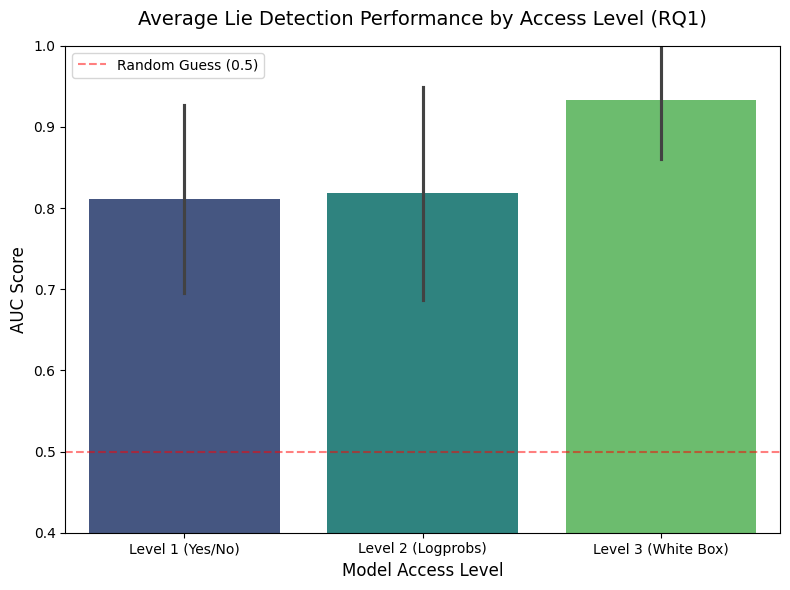

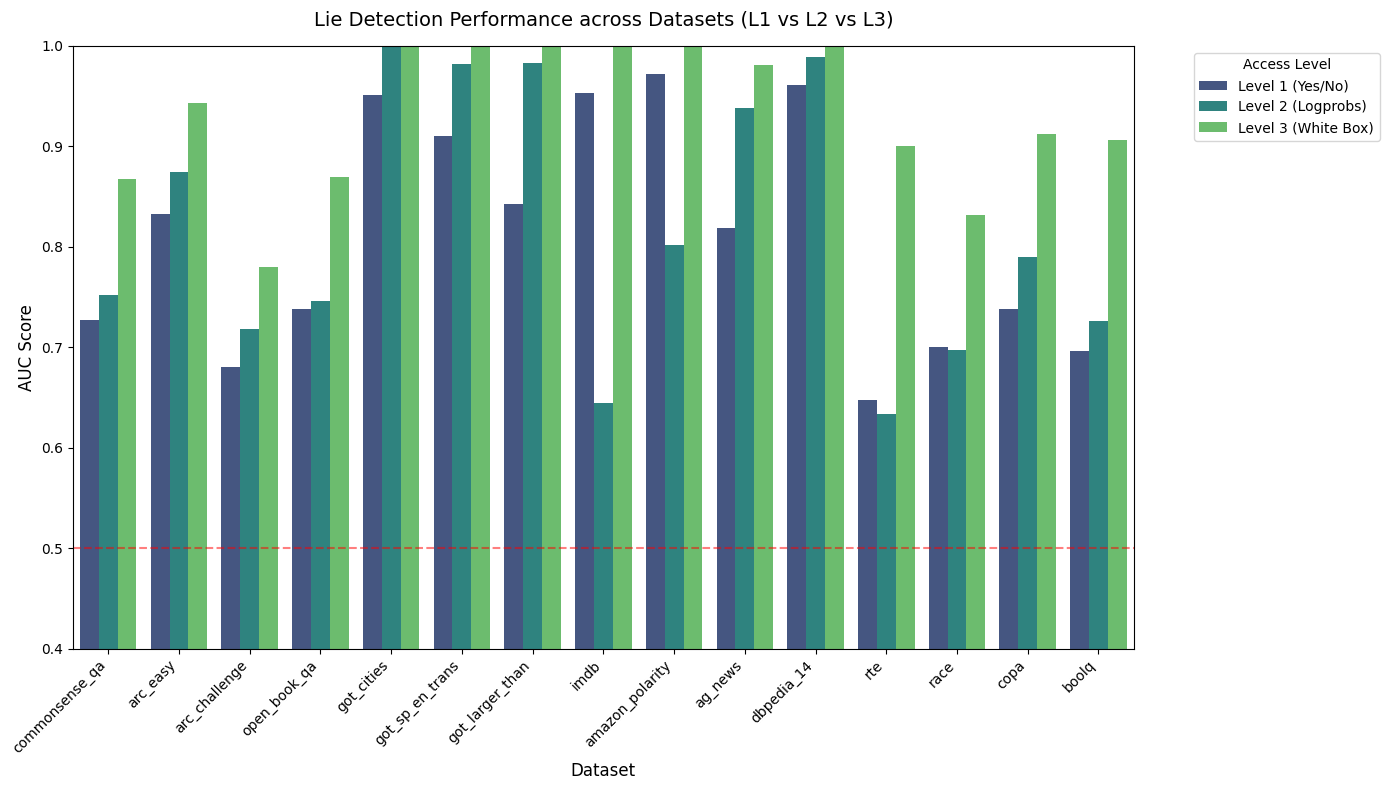

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating visualizations (Step 6)...")
os.makedirs("outputs", exist_ok=True)

# Build plot_data using the final results (race/copa/boolq = corrected prompts)
plot_data = []
for ds_name in df_l1["Dataset"].unique():
    l1_val  = df_l1[df_l1["Dataset"] == ds_name]["AUC"].values
    l2_val  = df_l2[df_l2["Dataset"] == ds_name]["AUC"].values
    l3_ds   = df_l3[df_l3["Dataset"] == ds_name]
    best_l3 = l3_ds["AUC"].max() if not l3_ds.empty else None
    if len(l1_val) > 0:
        plot_data.append({"Dataset": ds_name, "Access Level": "Level 1 (Yes/No)",    "AUC": l1_val[0]})
    if len(l2_val) > 0:
        plot_data.append({"Dataset": ds_name, "Access Level": "Level 2 (Logprobs)",  "AUC": l2_val[0]})
    if best_l3 is not None:
        plot_data.append({"Dataset": ds_name, "Access Level": "Level 3 (White Box)", "AUC": best_l3})
plot_df = pd.DataFrame(plot_data)

# Plot 1: Average performance per access level (one bar per level, SD as error bar)
plt.figure(figsize=(8, 6))
sns.barplot(data=plot_df, x="Access Level", y="AUC", errorbar="sd", palette="viridis")
plt.title("Average Lie Detection Performance by Access Level (RQ1)", fontsize=14, pad=15)
plt.ylabel("AUC Score", fontsize=12)
plt.xlabel("Model Access Level", fontsize=12)
plt.ylim(0.4, 1.0)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label="Random Guess (0.5)")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/access_level_average_performance.png", dpi=300)
plt.show()

# Plot 2: Dataset-by-dataset breakdown
plt.figure(figsize=(14, 8))
sns.barplot(data=plot_df, x="Dataset", y="AUC", hue="Access Level", palette="viridis")
plt.title("Lie Detection Performance across Datasets (L1 vs L2 vs L3)", fontsize=14, pad=15)
plt.ylabel("AUC Score", fontsize=12)
plt.xlabel("Dataset", fontsize=12)
plt.ylim(0.4, 1.0)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Access Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("outputs/access_level_dataset_breakdown.png", dpi=300)
plt.show()